<a href="https://colab.research.google.com/github/knogle01/CO2-and-pollutant-emissions-from-vehicles-sold-in-France/blob/main/Another_copy_of_Data_exploration_Chris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Mount Drive and Install Packages and load data

In [38]:
from google.colab import drive
import os

# Ensure the mount point is clean before attempting to mount
if os.path.exists('/content/drive'):
    # If it's a mount point, try to unmount it first
    if os.path.ismount('/content/drive'):
        print("Drive is already mounted. Attempting to unmount...")
        try:
            drive.flush_and_unmount()
            print("Drive unmounted successfully.")
        except Exception as e:
            print(f"Could not unmount Drive: {e}. Proceeding with directory cleanup.")

    # If the directory still exists and is not empty, forcefully remove it and its contents
    if os.path.exists('/content/drive') and os.path.isdir('/content/drive') and os.listdir('/content/drive'):
        print("Mountpoint /content/drive still contains files. Removing directory...")
        # Use !rm -rf for a forceful removal of the directory and its contents
        !rm -rf /content/drive
        print("Directory /content/drive removed.")

# Recreate the empty directory if it doesn't exist (after removal or if it never existed)
if not os.path.exists('/content/drive'):
    os.makedirs('/content/drive')

print("Attempting to mount Drive...")
drive.mount('/content/drive', force_remount=True)

# Export-Path
from pathlib import Path

EXPORT_DIR = Path("/content/drive/MyDrive/Plots")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)  # Ensure folder exists


Drive is already mounted. Attempting to unmount...
Drive unmounted successfully.
Attempting to mount Drive...
Mounted at /content/drive


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans

# Data Import

In [109]:
# Export-Path
from pathlib import Path

EXPORT_DIR = Path("/content/drive/MyDrive/Plots")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Define the path to your CSV file in Google Drive
file_path = '/content/drive/MyDrive/cl_JUIN_2013-complet3.csv'

# Load the dataset into a pandas DataFrame, specifying 'latin1' encoding
df = pd.read_csv(file_path, sep=";", encoding='latin1')

#Show all columns
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)

## Rename Column Names and Modalities

In [147]:
# Rename Column Names
column_mapping = {
    "Marque": "Brand",
    "Modèle dossier": "Folder Model",
    "Modèle UTAC": "Utac Model",
    "Désignation commerciale": "Commerical Designation",
    "CNIT": "cnit",
    "Type Variante Version (TVV)": "Type Variant Version",
    "Carburant": "Fuel",
    "Hybride": "Hybrid",
    "Puissance administrative": "Administrative Power",
    "Puissance maximale (kW)": "Maximum Power (kW)",
    "Boîte de vitesse": "Gearbox",
    "Consommation urbaine (l/100km)": "Urban Consumption (l/100km)",
    "Consommation extra-urbaine (l/100km)": "Extra Urban Consumption (l/100km)",
    "Consommation mixte (l/100km)": "Combined Consumption (l/100km)",
    "CO2 (g/km)": "CO2 (g/km)",
    "CO type I (g/km)": "CO type 1 (g/km)",
    "HC (g/km)": "HC (g/km)",
    "NOX (g/km)": "NOX (g/km)",
    "HC+NOX (g/km)": "HC+NOX (g/km)",
    "Particules (g/km)": "Particles (g/km)",
    "masse vide euro min (kg)": "Empty_Mass Euro Min (kg)",
    "masse vide euro max (kg)": "Empty_Mass Euro Max (kg)",
    "Champ V9": "Field V9",
    "Date de mise à jour": "Update Date",
    "Carrosserie": "Body",
    "gamme": "Range"
}

df = df.rename(columns=column_mapping)
df.head()


,Brand,Folder Model,Utac Model,Commerical Designation,cnit,Type Variant Version,Fuel,Hybrid,Administrative Power,Maximumn Power (kW),Gearbox,Urban Consumption (l/100km),Extra Urban Consumption (l/100km),Combined Consumption (l/100km),CO2 (g/km),CO type 1 (g/km),HC (g/km),NOX (g/km),HC+NOX (g/km),Particles (g/km),Field V9,Update Date,Body,Range,gearbox,Empty_Mass Euro Avg (kg),Weight_to_Power_Ratio (kg/kW),Power_to_Weight_Ratio (kW/kg)
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147.0,M 6,11.3,5.8,7.8,182.0,0.647,0.052,0.032,0.084,0.002,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER,M 6,1505.0,10.238095,0.097674
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,125.0,M 6,6.6,4.3,5.1,136.0,0.192,0.021,0.169,0.190,0.003,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER,M 6,1565.0,12.520000,0.079872
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100.0,M 6,6.6,4.2,5.1,134.0,0.066,0.026,0.149,0.175,0.001,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER,M 6,1565.0,15.650000,0.063898
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100.0,M 6,6.6,4.2,5.1,134.0,0.066,0.026,0.149,0.175,0.001,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER,M 6,1565.0,15.650000,0.063898
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125.0,M 6,6.9,4.3,5.3,139.0,0.060,0.029,0.164,0.193,0.001,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER,M 6,1565.0,12.520000,0.079872


## Overview of the data columns

In [112]:
datatypes = df.dtypes
print(datatypes)

Brand                                 object
Folder Model                          object
Utac Model                            object
Commerical Designation                object
cnit                                  object
Type Variant Version                  object
Fuel                                  object
Hybrid                                object
Administrative Power                   int64
Maximumn Power (kW)                  float64
Gearbox                               object
Urban Consumption (l/100km)          float64
Extra Urban Consumption (l/100km)    float64
Combined Consumption (l/100km)       float64
CO2 (g/km)                           float64
CO type 1 (g/km)                     float64
HC (g/km)                            float64
NOX (g/km)                           float64
HC+NOX (g/km)                        float64
Particles (g/km)                     float64
Empty_Mass Euro Min (kg)               int64
Empty_Mass Euro Max (kg)               int64
Field V9  

# Data preview

In [113]:
df.head(10)

,Brand,Folder Model,Utac Model,Commerical Designation,cnit,Type Variant Version,Fuel,Hybrid,Administrative Power,Maximumn Power (kW),Gearbox,Urban Consumption (l/100km),Extra Urban Consumption (l/100km),Combined Consumption (l/100km),CO2 (g/km),CO type 1 (g/km),HC (g/km),NOX (g/km),HC+NOX (g/km),Particles (g/km),Empty_Mass Euro Min (kg),Empty_Mass Euro Max (kg),Field V9,Update Date,Body,Range
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147.0,M 6,11.3,5.8,7.8,182.0,0.647,0.052,0.032,NaN,0.002,1505,1505,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,125.0,M 6,6.6,4.3,5.1,136.0,0.192,NaN,0.169,0.190,0.003,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100.0,M 6,6.6,4.2,5.1,134.0,0.066,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100.0,M 6,6.6,4.2,5.1,134.0,0.066,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125.0,M 6,6.9,4.3,5.3,139.0,0.060,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
5,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000H305,939AXS1B66B,GO,non,9,125.0,M 6,6.9,4.3,5.3,139.0,0.060,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
6,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147.0,M 6,11.5,6.0,8.0,186.0,0.647,0.052,0.032,NaN,0.002,1555,1555,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
7,ALFA-ROMEO,159,159,159 SW 2.0 JTDm (170ch) ECO,M10ALFVP000S255,939BXP1B55C,GO,non,9,125.0,M 6,6.7,4.4,5.2,139.0,0.192,NaN,0.169,0.190,0.003,1615,1615,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
8,ALFA-ROMEO,159,159,159 SW 2.0 JTDm (136ch),M10ALFVP000J306,939BXR1B65,GO,non,7,100.0,M 6,6.8,4.3,5.2,137.0,0.066,NaN,0.149,0.175,0.001,1615,1615,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
9,ALFA-ROMEO,159,159,159 SW 2.0 JTDm (136ch),M10ALFVP000J307,939BXR1B65B,GO,non,7,100.0,M 6,6.8,4.3,5.2,137.0,0.066,NaN,0.149,0.175,0.001,1615,1615,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER


# Data preprocessing

## Missing values

In [114]:
# Count of missing values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

HC (g/km)                            34447
HC+NOX (g/km)                        10659
Particles (g/km)                      3142
CO type 1 (g/km)                       303
NOX (g/km)                             303
Field V9                               235
Extra Urban Consumption (l/100km)       42
Urban Consumption (l/100km)             42
Combined Consumption (l/100km)          39
CO2 (g/km)                              39
dtype: int64


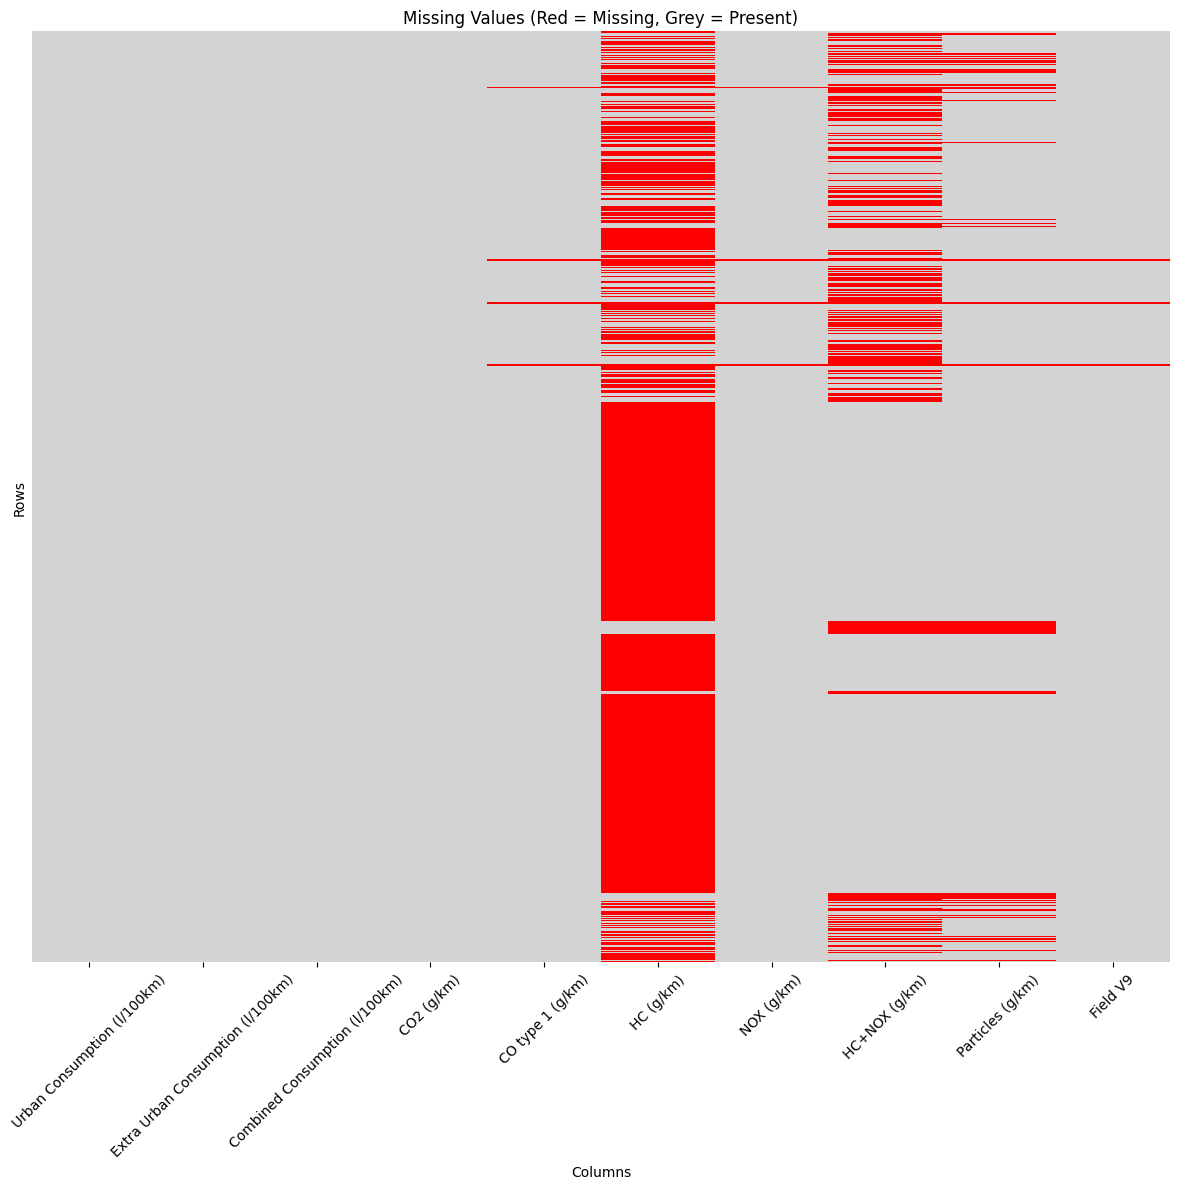

In [115]:
from matplotlib.colors import ListedColormap

# Define cols_with_na using the index of missing_values (which has the renamed columns)
cols_with_na = missing_values[missing_values > 0].index.tolist()

# Define cmap, assuming a similar colormap as used elsewhere in the notebook
cmap = ListedColormap(["lightgrey", "blue", "red"])

plt.figure(figsize=(12,12))
sns.heatmap(df[cols_with_na].isna(),
            cbar=False,
            cmap=cmap,
            yticklabels=False)

plt.title("Missing Values (Red = Missing, Grey = Present)")
plt.xticks(rotation=45)
plt.ylabel("Rows")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

## Data Cleaning

In [116]:
# Calculate missing pollutant values from HC+NOX (g/km), NOX (g/km), HC (g/km)
df['hc_g_km_calc']  = df['HC+NOX (g/km)'] - df['NOX (g/km)']
df['nox_g_km_calc'] = df['HC+NOX (g/km)'] - df['HC (g/km)']

df['hc_g_km_calc']  = df['hc_g_km_calc'].fillna(df['HC (g/km)'])
df['nox_g_km_calc'] = df['nox_g_km_calc'].fillna(df['NOX (g/km)'])

df['hc_nox_g_km_calc'] = df['hc_g_km_calc'] + df['nox_g_km_calc']

df["HC (g/km)"] = df["hc_g_km_calc"]
df["NOX (g/km)"] = df["nox_g_km_calc"]
df["HC+NOX (g/km)"] = df["hc_nox_g_km_calc"]

# Drop the temporary calculation columns
df.drop(columns=['hc_g_km_calc', 'nox_g_km_calc', 'hc_nox_g_km_calc'], inplace=True)

display(df.isna().sum())

,0
Brand,0
Folder Model,0
Utac Model,0
Commerical Designation,0
cnit,0
Type Variant Version,0
Fuel,0
Hybrid,0
Administrative Power,0
Maximumn Power (kW),0


In [117]:
# Gearbox: Replace wrong data entries
df['gearbox'] = df['Gearbox'].replace(['N 0', 'N 1'], 'A 0')
df['Gearbox'] = df['Gearbox'].replace(['S 6'], 'D 6')

In [118]:
# Field V9: Replace wrong data entries
df['Field V9'] = df['Field V9'].replace(['715/2007*459/2012EUR'], '715/2007*459/2012EURO')

##Replace pollutant emission NaN values where fuel = EL (Electric) with zero



In [50]:
# Replace polutant NaN values for electric cars with zero (emissions)

electric_cols = ["CO type 1 (g/km)",
                 "Urban Consumption (l/100km)",
                 "Extra Urban Consumption (l/100km)",
                 "Combined Consumption (l/100km)",
                 "CO2 (g/km)", "HC+NOX (g/km)",
                 "HC (g/km)",
                 "Particles (g/km)"]

df.loc[df["Fuel"] == "EL", electric_cols] = 0

df[df["Fuel"] == "EL"].head()

df.isna().sum()

,0
Brand,0
Folder Model,0
Utac Model,0
Commerical Designation,0
cnit,0
Type Variant Version,0
Fuel,0
Hybrid,0
Administrative Power,0
Maximumn Power (K),0


## Calculate Average Mass

In [119]:
# Merge Empty_Mass Euro Min and Max into an average column

# Create the average column
df["Empty_Mass Euro Avg (kg)"] = (df["Empty_Mass Euro Min (kg)"] + df["Empty_Mass Euro Max (kg)"]) / 2

# Drop the original Min and Max columns
df.drop(columns=["Empty_Mass Euro Min (kg)", "Empty_Mass Euro Max (kg)"], inplace=True)

Calculate Weigth to Power Ratio

In [121]:
# Calculate weight-to-power ratio
df['Weight_to_Power_Ratio (kg/kW)'] = df['Empty_Mass Euro Avg (kg)'] / df['Maximumn Power (kW)']

## Calculate Power-to-Weight Ratio

## Calculate Power-to-Weight Ratio


In [140]:
df['Power_to_Weight_Ratio (kW/kg)'] = df['Maximumn Power (kW)'] / df['Empty_Mass Euro Avg (kg)']

# Exploratory Data Analysis

## Columns

In [99]:
summary = df.describe(include='all')
summary

,Brand,Folder Model,Utac Model,Commerical Designation,cnit,Type Variant Version,Fuel,Hybrid,Administrative Power,Maximumn Power (K),Gearbox,Urban Consumption (l/100km),Extra Urban Consumption (l/100km),Combined Consumption (l/100km),CO2 (g/km),CO type 1 (g/km),HC (g/km),NOX (g/km),HC+NOX (g/km),Particles (g/km),Field V9,Update Date,Body,Range,gearbox,Empty_Mass Euro Avg (kg)
count,44850,44850,44850,44850,44850,44850,44850,44850,44850.000000,44850.000000,44850,44847.000000,44847.000000,44850.000000,44850.000000,44586.000000,44586.000000,44586.000000,44586.000000,41747.000000,44615,44850,44850,44850,44850,44850.000000
unique,51,458,419,3582,44191,28781,13,2,NaN,NaN,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,3,10,7,13,NaN
top,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10LNCVP000R207,263AXG1B05,GO,non,NaN,NaN,M 6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-INFER,M 6,NaN
freq,38450,14031,14031,5874,16,32,37778,44593,NaN,NaN,19364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26426,43910,32744,20428,19364,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.018997,124.780834,NaN,9.698303,6.561923,7.709544,198.737926,0.153327,0.022389,0.311567,0.333956,0.000960,NaN,NaN,NaN,NaN,NaN,2120.253467
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.554475,49.158804,NaN,2.382396,1.211284,1.612537,39.435988,0.138997,0.014255,0.463000,0.458279,0.006466,NaN,NaN,NaN,NaN,NaN,375.342780
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,10.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,-0.054000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,825.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,100.000000,NaN,8.800000,6.300000,7.200000,187.000000,0.046000,0.011000,0.158000,0.180000,0.000000,NaN,NaN,NaN,NaN,NaN,2025.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,120.000000,NaN,9.700000,6.700000,7.700000,203.000000,0.093000,0.019000,0.197000,0.216000,0.001000,NaN,NaN,NaN,NaN,NaN,2130.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,125.000000,NaN,10.700000,7.100000,8.400000,221.000000,0.222000,0.030000,0.228000,0.253000,0.001000,NaN,NaN,NaN,NaN,NaN,2299.000000


## Distribution by Fuel Type (Energy)

/tmp/ipykernel_255/3563186190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fuel', order=df['Fuel'].value_counts().index, palette='viridis')


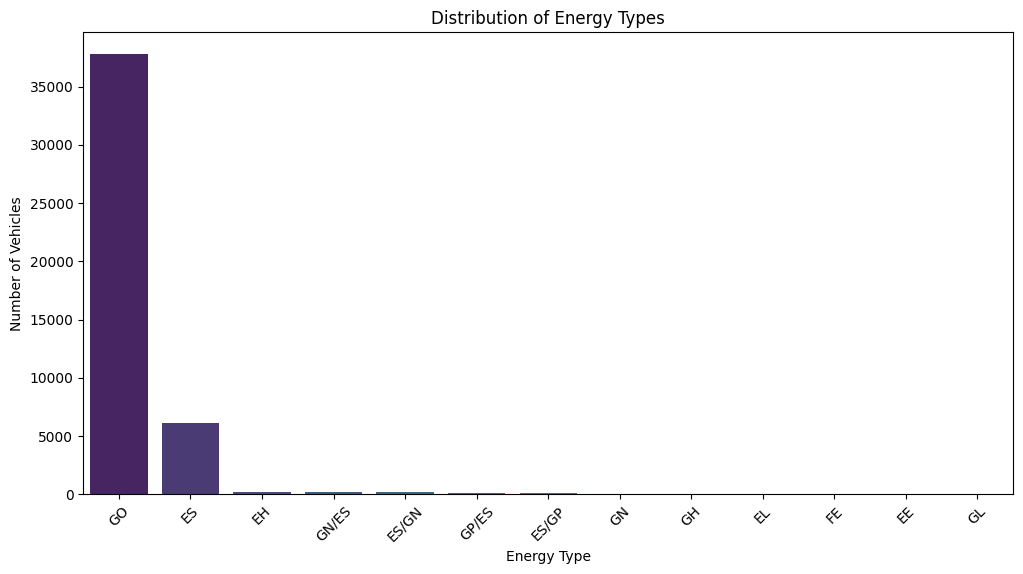

In [100]:
# Visualization of the distribution of energy types
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Fuel', order=df['Fuel'].value_counts().index, palette='viridis')

plt.title('Distribution of Energy Types')
plt.xlabel('Energy Type')
plt.ylabel('Number of Vehicles')

plt.xticks(rotation=45)

plt.show()

/tmp/ipykernel_255/2139076222.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Brand', order=df['Brand'].value_counts().index, palette='viridis')


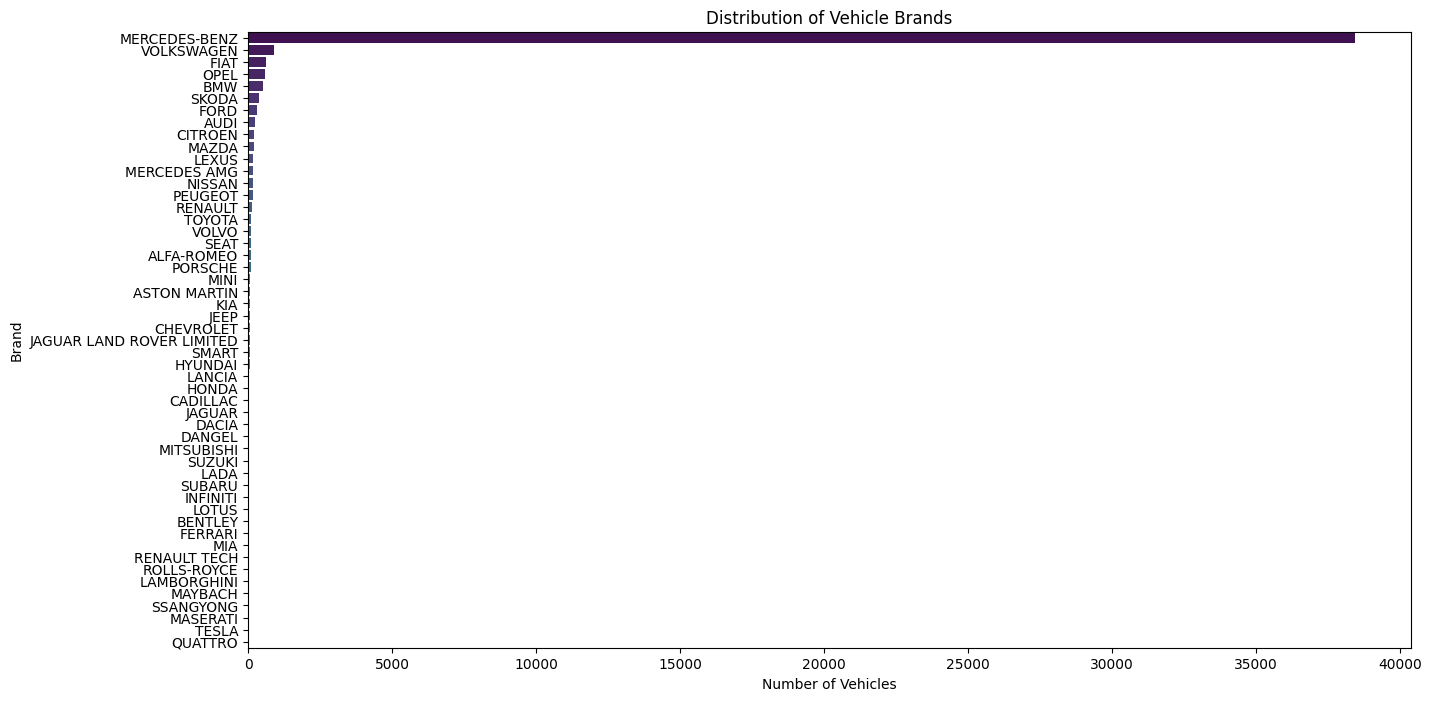

In [101]:
# Visualization of the distribution of vehicle brands
plt.figure(figsize=(15, 8))
sns.countplot(data=df, y='Brand', order=df['Brand'].value_counts().index, palette='viridis')

plt.title('Distribution of Vehicle Brands')
plt.xlabel('Number of Vehicles')
plt.ylabel('Brand')

plt.show()

/tmp/ipykernel_255/1975756238.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_counts.index, y=model_counts.values, palette='viridis')


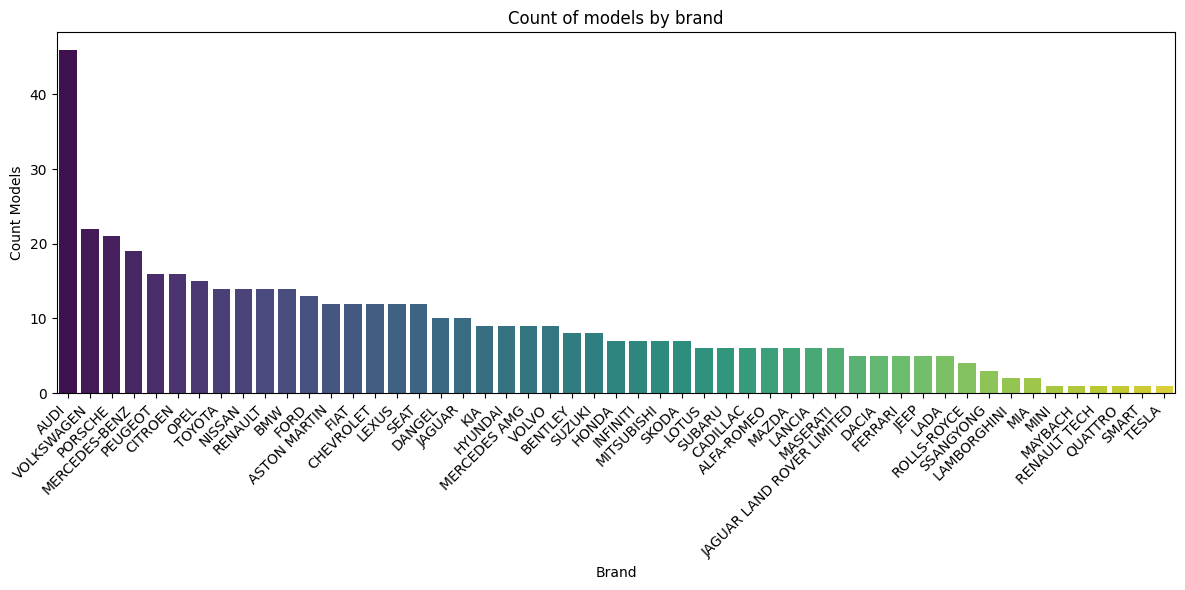

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

model_counts = df.groupby("Brand")["Folder Model"].nunique().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=model_counts.index, y=model_counts.values, palette='viridis')

plt.grid(False)
plt.xlabel("Brand")
plt.ylabel("Count Models")
plt.title("Count of models by brand")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

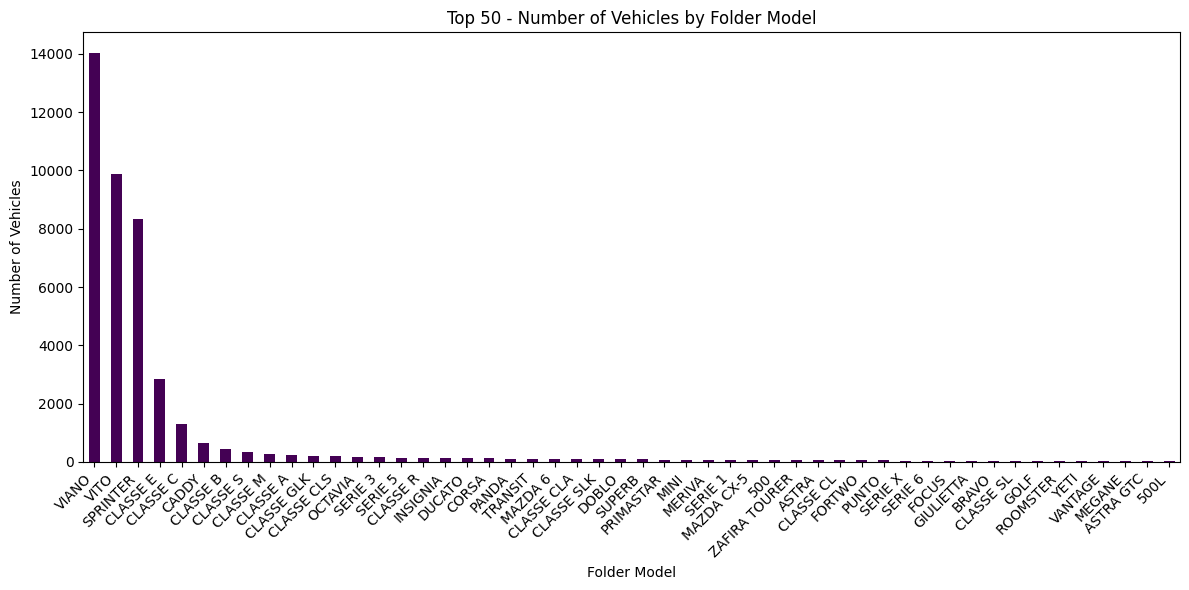

In [103]:
# Top 50 - Number of Vehicles by Folder Model
top_n = 50

model_counts = df["Folder Model"].value_counts().head(top_n)


plt.figure(figsize=(12, 6))
model_counts.plot(kind="bar",colormap="viridis")

plt.xlabel("Folder Model")
plt.ylabel("Number of Vehicles")
plt.title("Top 50 - Number of Vehicles by Folder Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

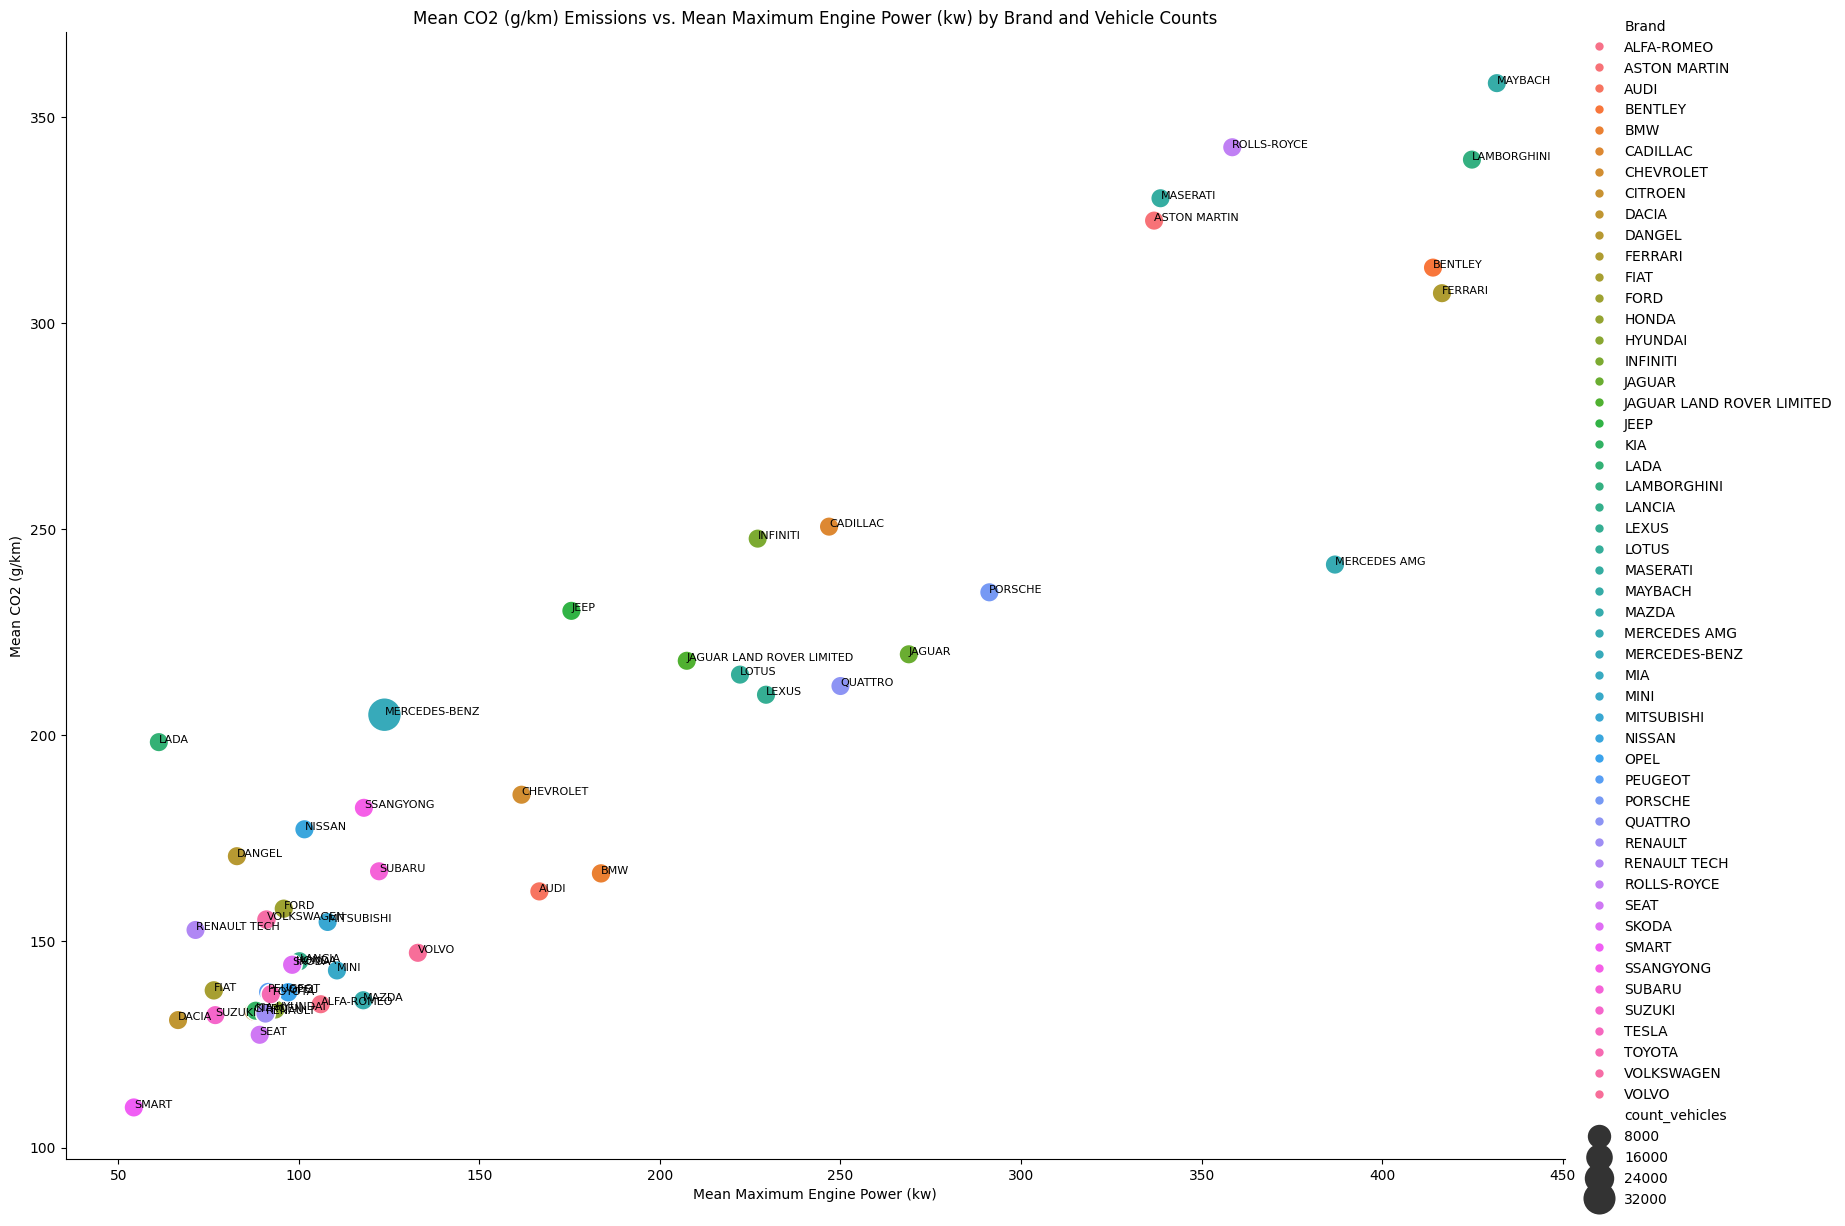

In [207]:
df_grouped_brand = df.groupby('Brand').agg(
    mean_co2_g_km=('CO2 (g/km)', 'mean'),
    mean_avg_empty_mass=('Empty_Mass Euro Avg (kg)', 'mean'),
    mean_maximum_power_kw=('Maximumn Power (kW)', 'mean'),
    mean_combined_consumption_l_100km=('Combined Consumption (l/100km)', 'mean'),
    count_vehicles=('Brand', 'count')
).reset_index()

power =sns.relplot(
    x="mean_maximum_power_kw",
    y="mean_co2_g_km",
    data=df_grouped_brand,
    kind="scatter",
    hue="Brand",
    height=12,
    aspect=8/6,
    sizes=(200, 600),
    size="count_vehicles"
)
powerx = power.ax
for i, row in df_grouped_brand.iterrows():
    powerx.text(
        row["mean_maximum_power_kw"],
        row["mean_co2_g_km"],
        row["Brand"],
        fontsize=8,
    )
plt.title("Mean CO2 (g/km) Emissions vs. Mean Maximum Engine Power (kw) by Brand and Vehicle Counts")
plt.xlabel("Mean Maximum Engine Power (kw)")
plt.ylabel("Mean CO2 (g/km)")
plt.savefig(EXPORT_DIR / "Mean CO2 (g_km) Emissions vs. Maximum Engine Power (kw) by Brand and Vehicle Counts.png", dpi=300, bbox_inches="tight")

plt.show()

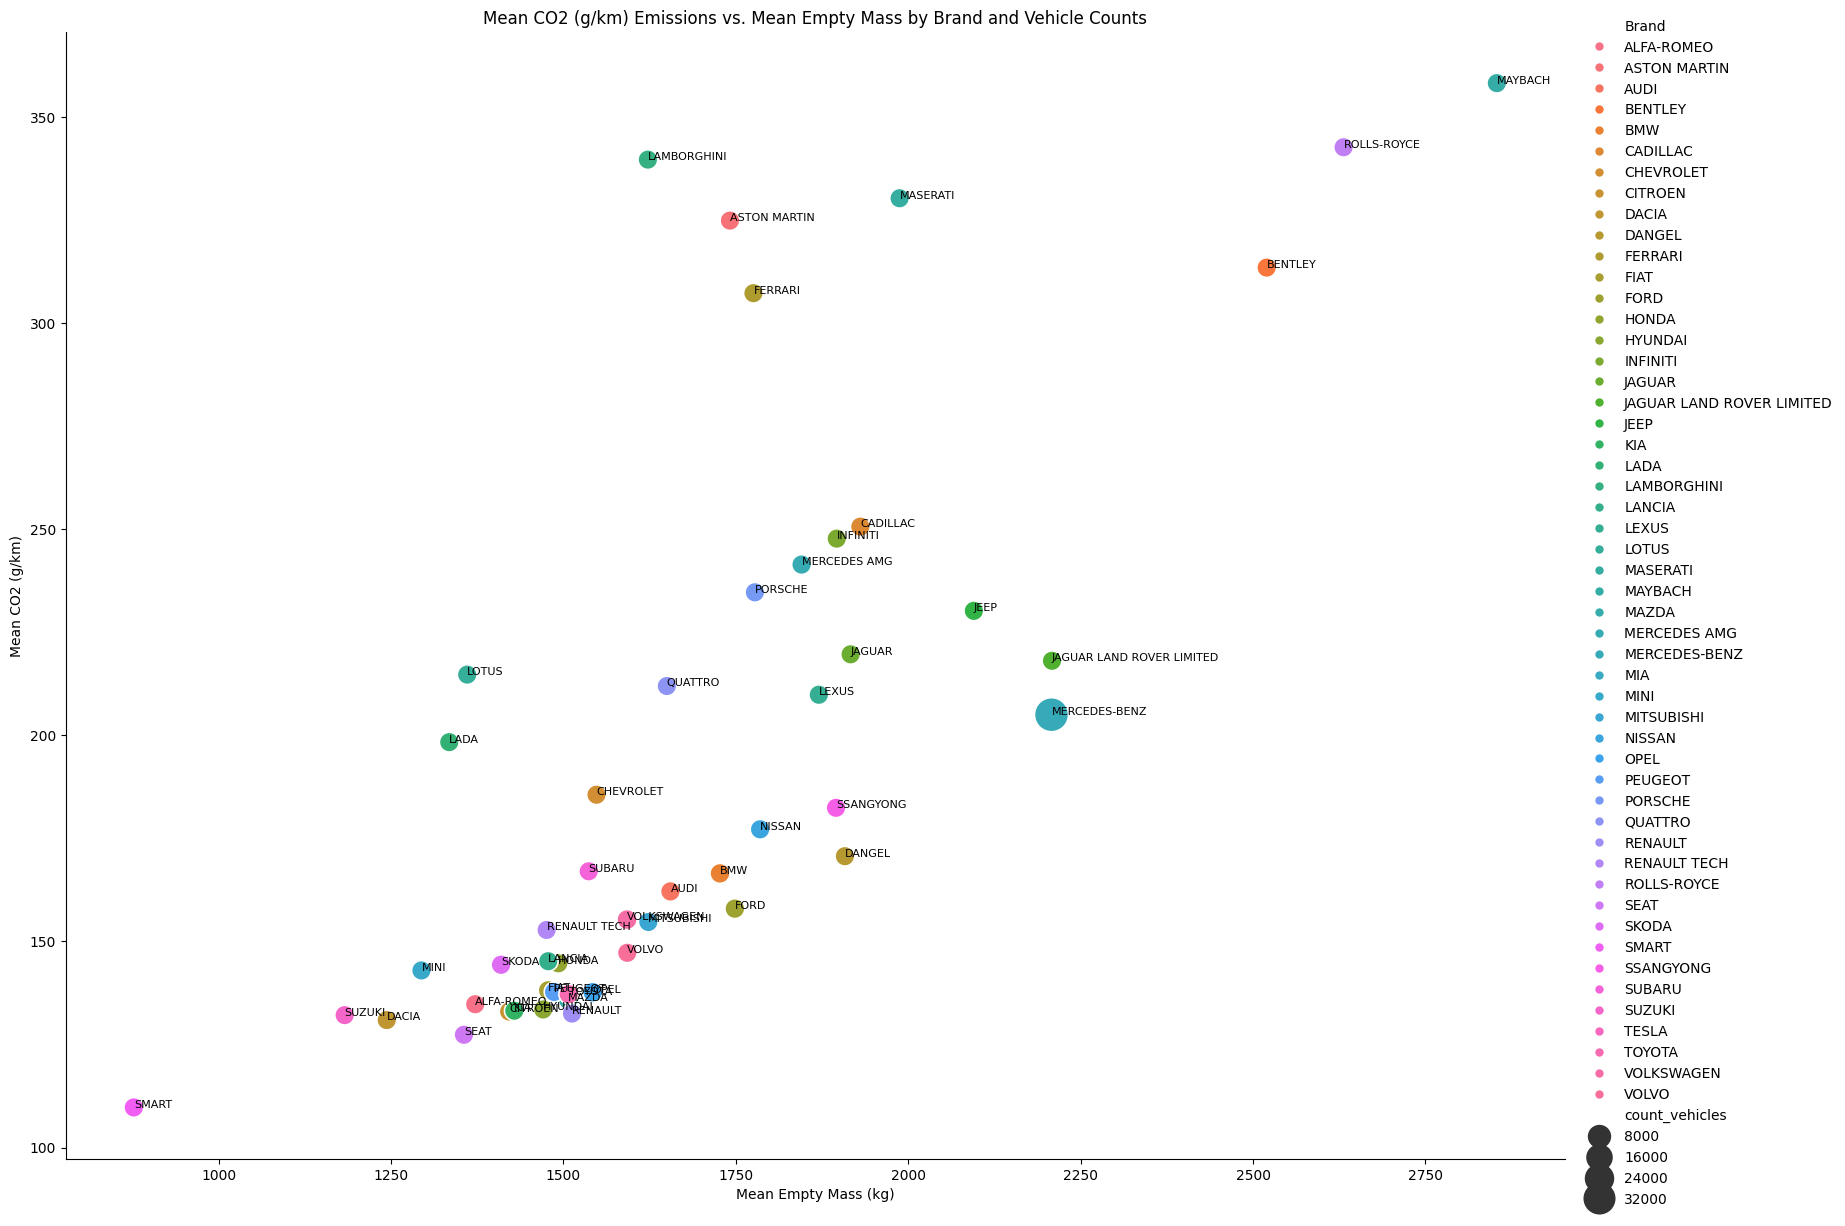

In [208]:
mass = sns.relplot(
    x="mean_avg_empty_mass",
    y="mean_co2_g_km",
    data=df_grouped_brand,
    kind="scatter",
    hue="Brand", # Changed to 'Brand'
    height=12,
    aspect=8/6,
    sizes=(200, 600),
    size="count_vehicles"
)

massx = mass.ax

for i, row in df_grouped_brand.iterrows():
    massx.text(
        row["mean_avg_empty_mass"],
        row["mean_co2_g_km"],
        row["Brand"], # Changed to 'Brand'
        fontsize=8,
    )

plt.title("Mean CO2 (g/km) Emissions vs. Mean Empty Mass by Brand and Vehicle Counts")
plt.xlabel("Mean Empty Mass (kg)")
plt.ylabel("Mean CO2 (g/km)")

plt.savefig(
    EXPORT_DIR / "Mean CO2 (g_km) Emissions vs Mean Empty Mass by Brand and Vehicle Counts.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Distribution of Power Variables

/tmp/ipykernel_255/2584051386.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Power Variables', y='Value', data=melted_data, palette="viridis")


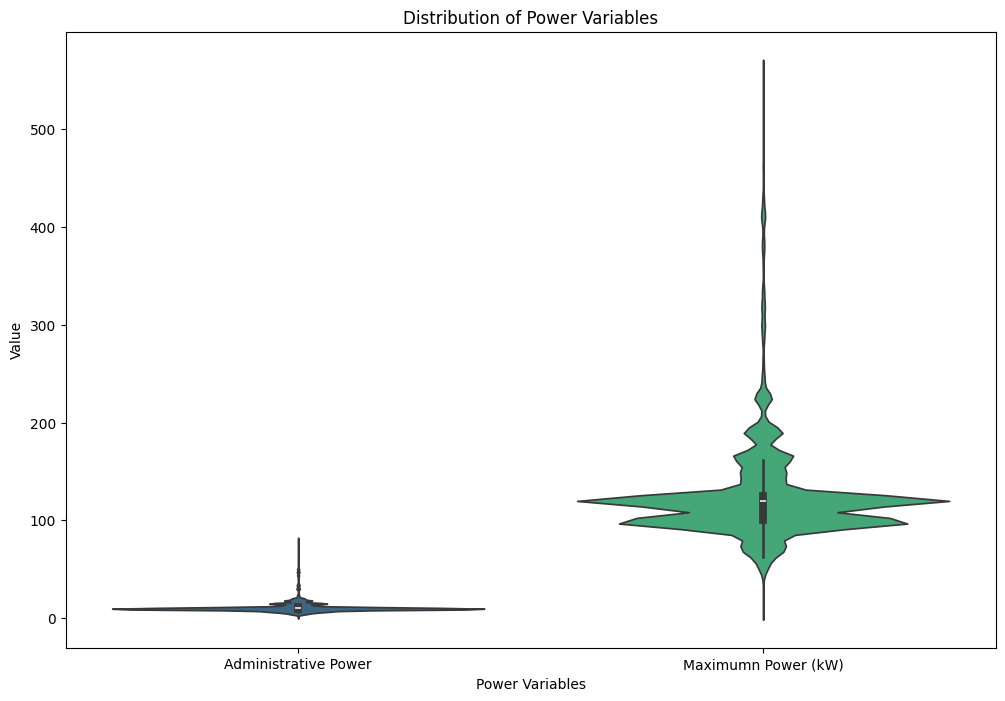

In [197]:
# Prepare the data for the violin plot
melted_data = df.melt(value_vars=['Administrative Power', 'Maximumn Power (kW)'],
                        var_name='Power Variables', value_name='Value')

# Create the violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x='Power Variables', y='Value', data=melted_data, palette="viridis")

plt.title('Distribution of Power Variables')
plt.ylabel('Value')
plt.xlabel('Power Variables')

plt.show()

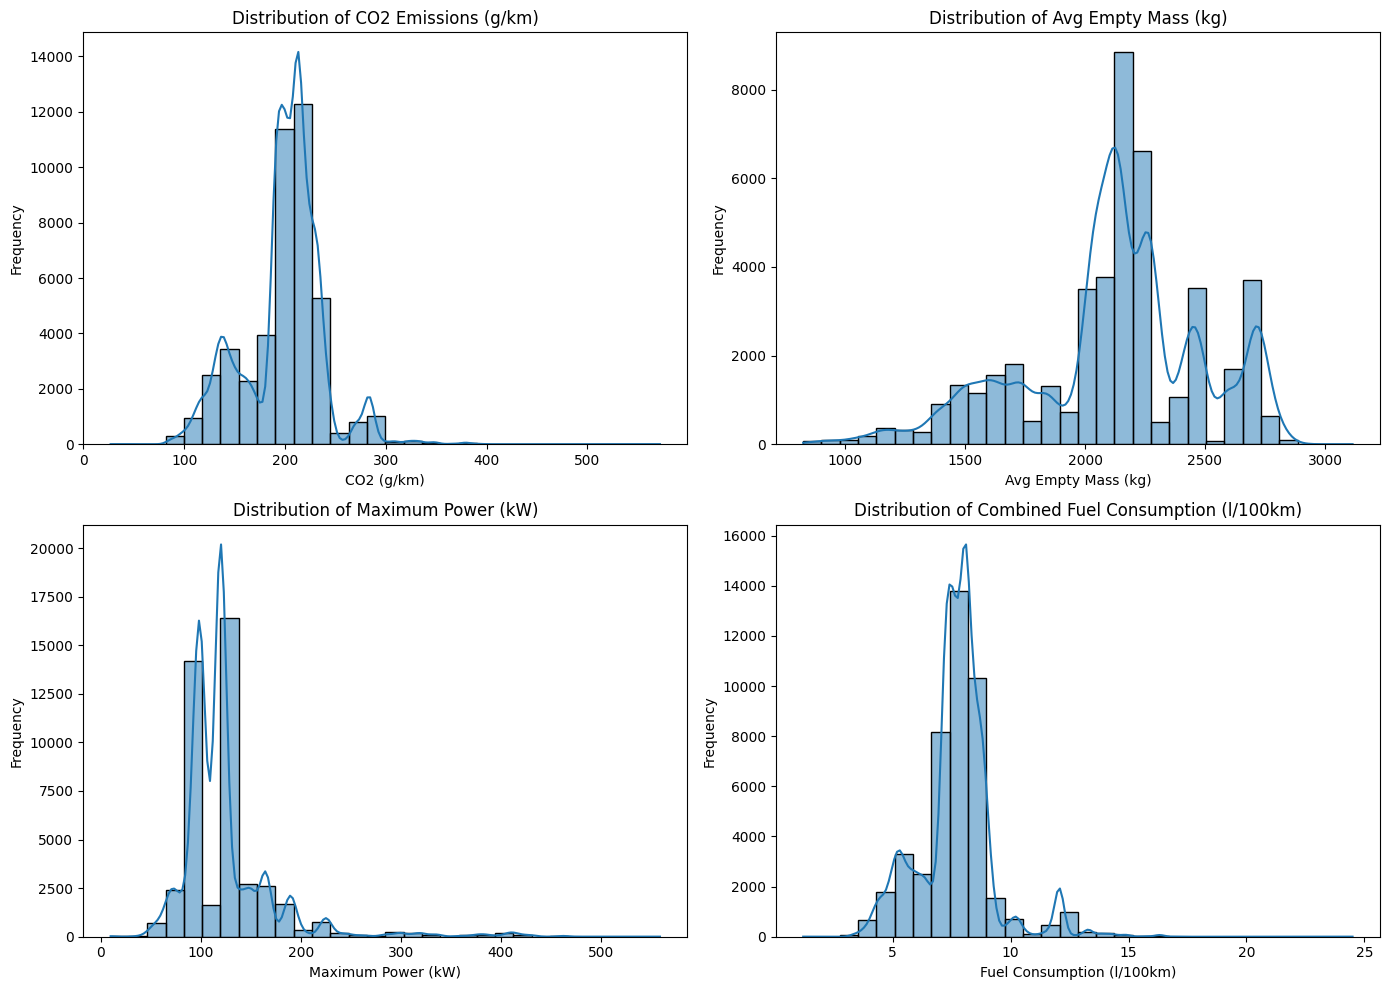

In [199]:
# Create histograms for selected variables
plt.figure(figsize=(14, 10))

# CO2 emissions
plt.subplot(2, 2, 1)
sns.histplot(df['CO2 (g/km)'], bins=30, kde=True)
plt.title('Distribution of CO2 Emissions (g/km)')
plt.xlabel('CO2 (g/km)')
plt.ylabel('Frequency')

# Vehicle mass
plt.subplot(2, 2, 2)
sns.histplot(df['Empty_Mass Euro Avg (kg)'], bins=30, kde=True)
plt.title('Distribution of Avg Empty Mass (kg)')
plt.xlabel('Avg Empty Mass (kg)')
plt.ylabel('Frequency')

# Maximum power
plt.subplot(2, 2, 3)
sns.histplot(df['Maximumn Power (kW)'], bins=30, kde=True)
plt.title('Distribution of Maximum Power (kW)')
plt.xlabel('Maximum Power (kW)')
plt.ylabel('Frequency')

# Fuel consumption
plt.subplot(2, 2, 4)
sns.histplot(df['Combined Consumption (l/100km)'], bins=30, kde=True)
plt.title('Distribution of Combined Fuel Consumption (l/100km)')
plt.xlabel('Fuel Consumption (l/100km)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Correlations of numeric data

## Distribution of CO2 Emission by brand, fuel, range

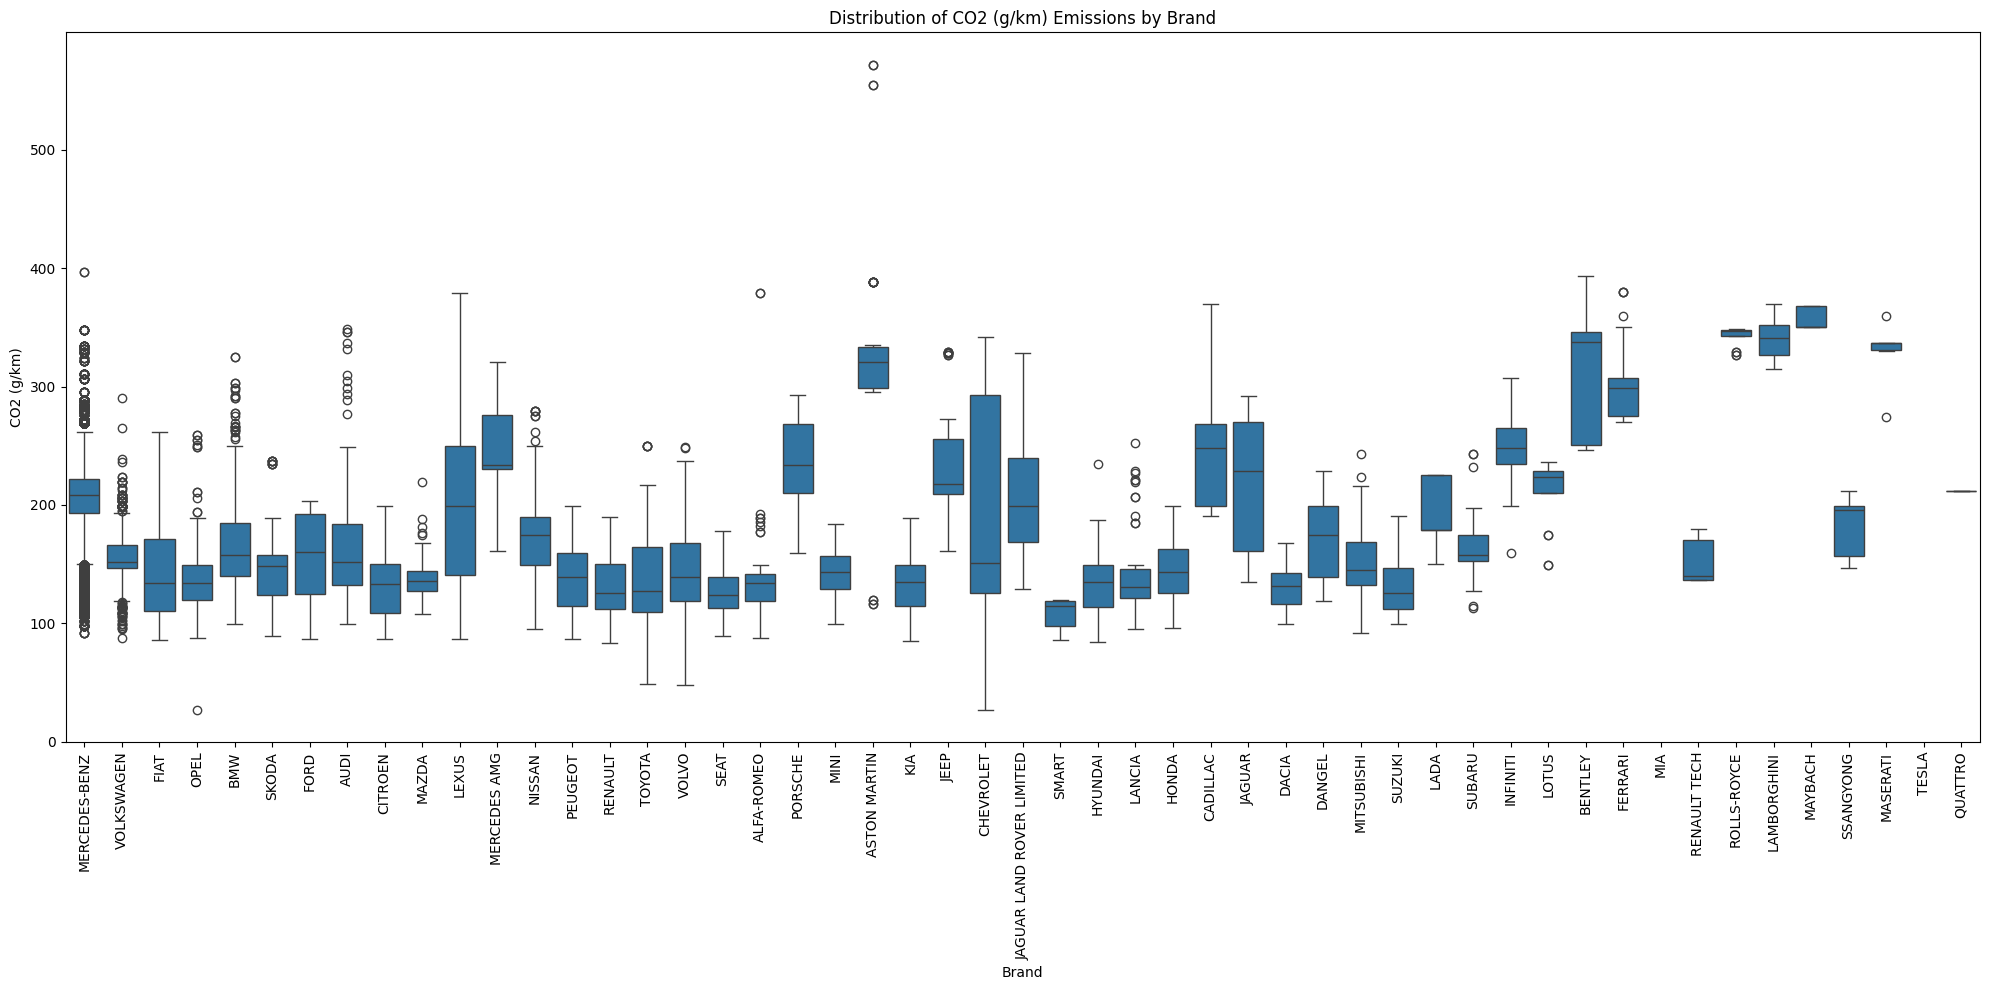

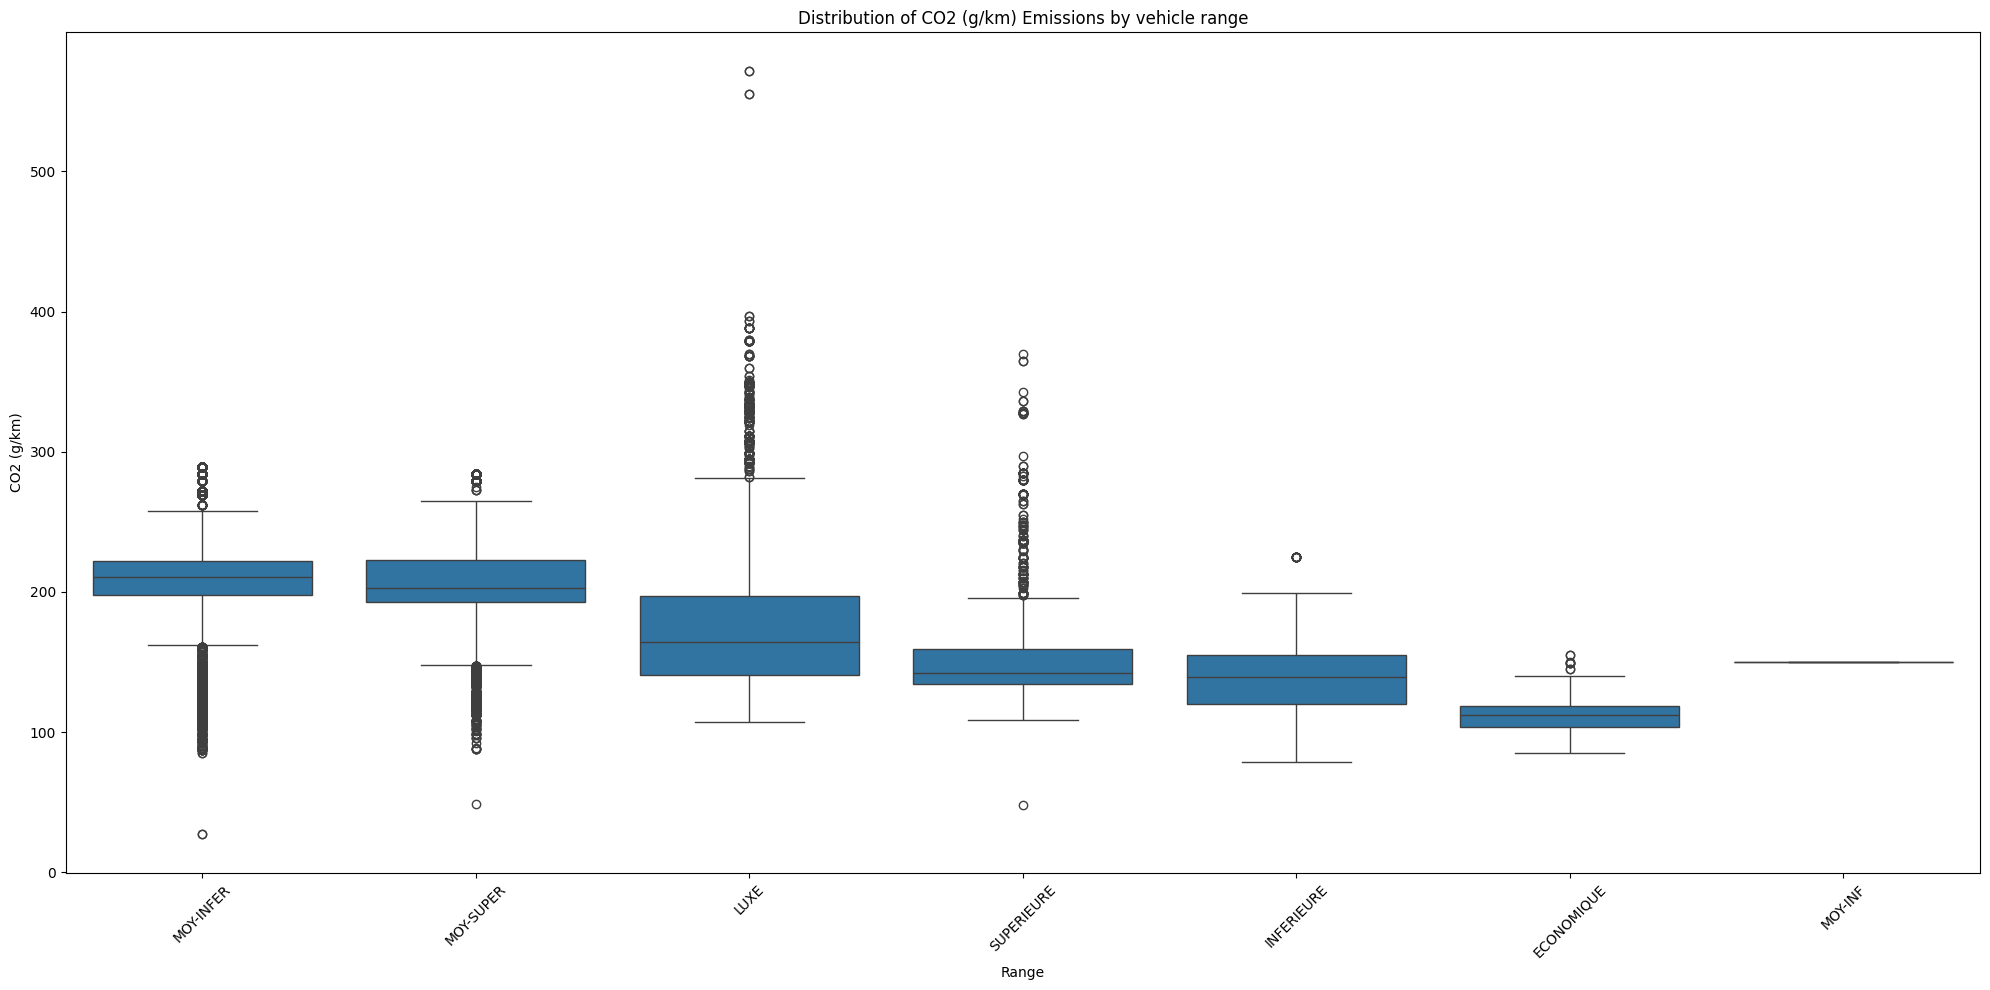

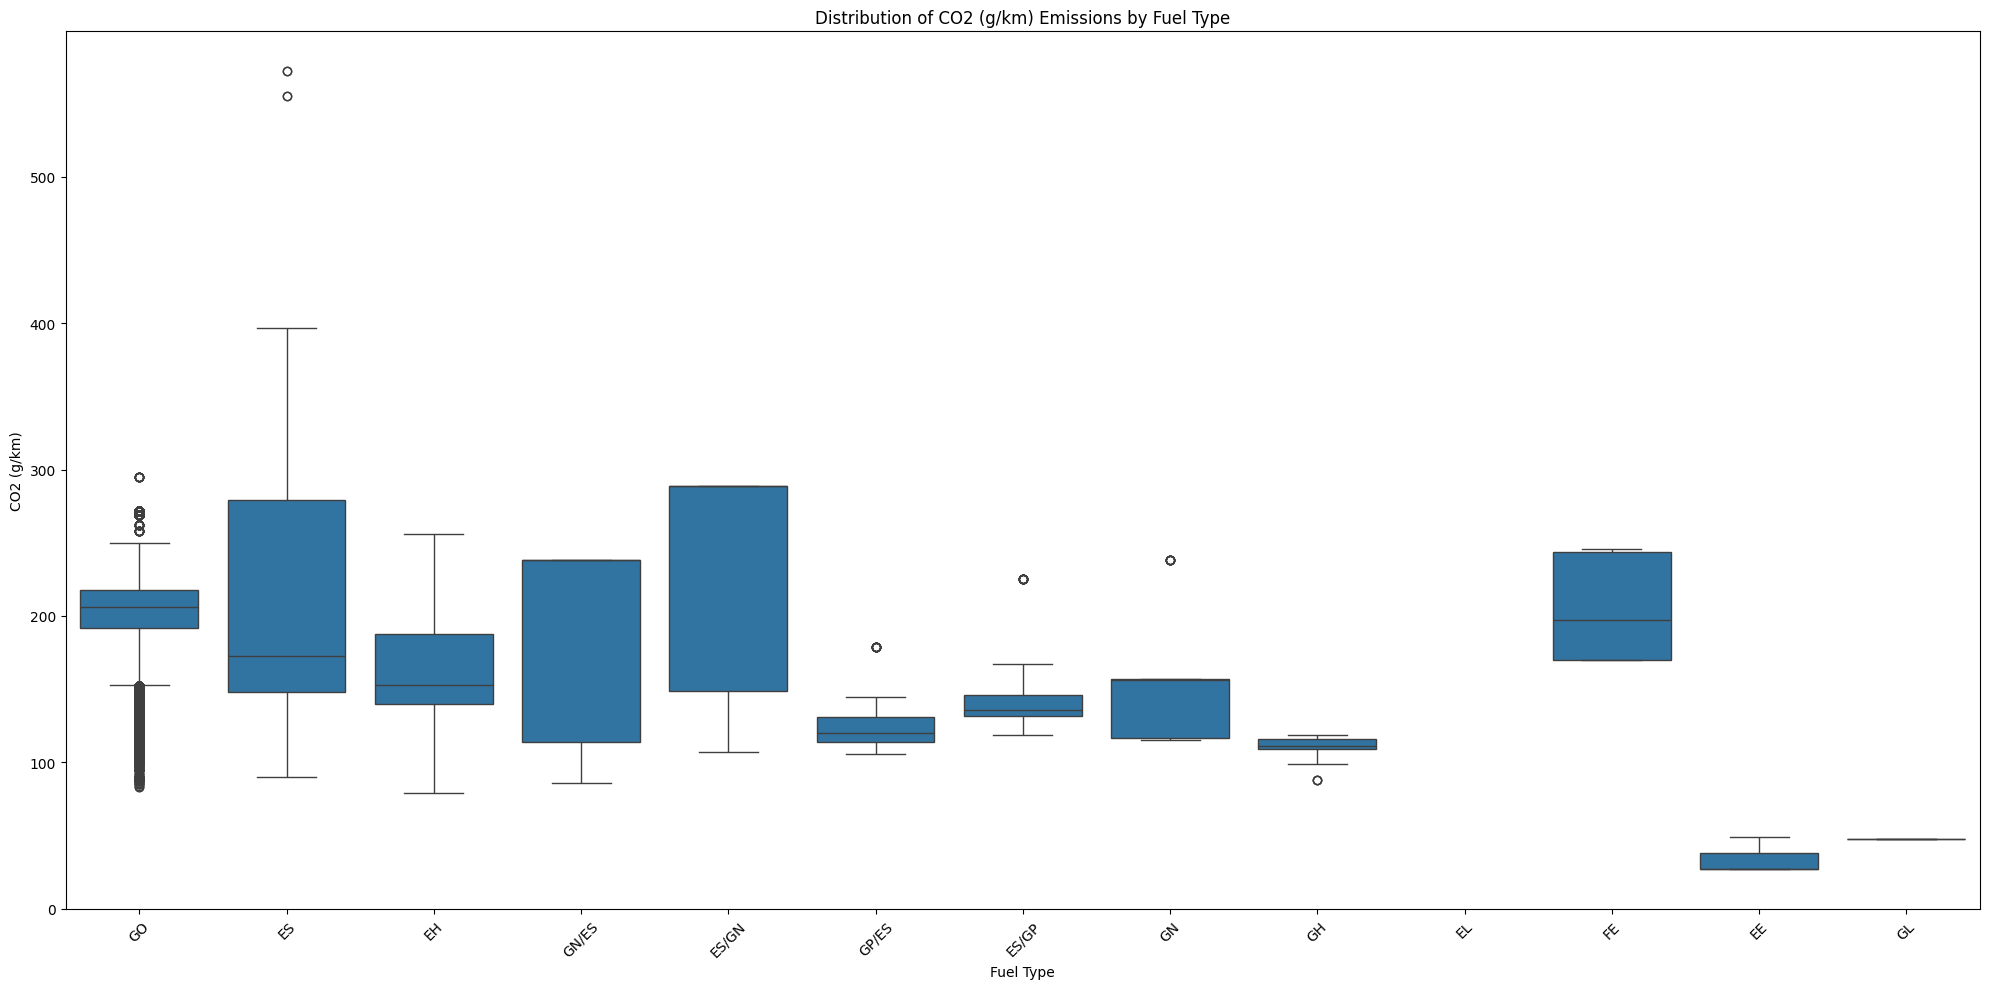

In [126]:
# Plot boxplots for CO2 emissions for all brands
plt.figure(figsize=(20, 10))
sns.boxplot(x='Brand', y='CO2 (g/km)', data=df, order=df['Brand'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of CO2 (g/km) Emissions by Brand')
plt.xlabel('Brand')
plt.ylabel('CO2 (g/km)')
plt.tight_layout()
plt.show()

# Plot boxplots for CO2 emissions per vehicle range ("Gamme")
plt.figure(figsize=(20, 10))
sns.boxplot(x='Range', y='CO2 (g/km)', data=df, order=df['Range'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of CO2 (g/km) Emissions by vehicle range')
plt.xlabel('Range')
plt.ylabel('CO2 (g/km)')
plt.tight_layout()
plt.show()

# Plot boxplots for CO2 emissions based on fuel type ("Energie")
plt.figure(figsize=(20, 10))
sns.boxplot(x='Fuel', y='CO2 (g/km)', data=df, order=df['Fuel'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of CO2 (g/km) Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('CO2 (g/km)')
plt.tight_layout()
plt.show()

## Correlations of numeric data

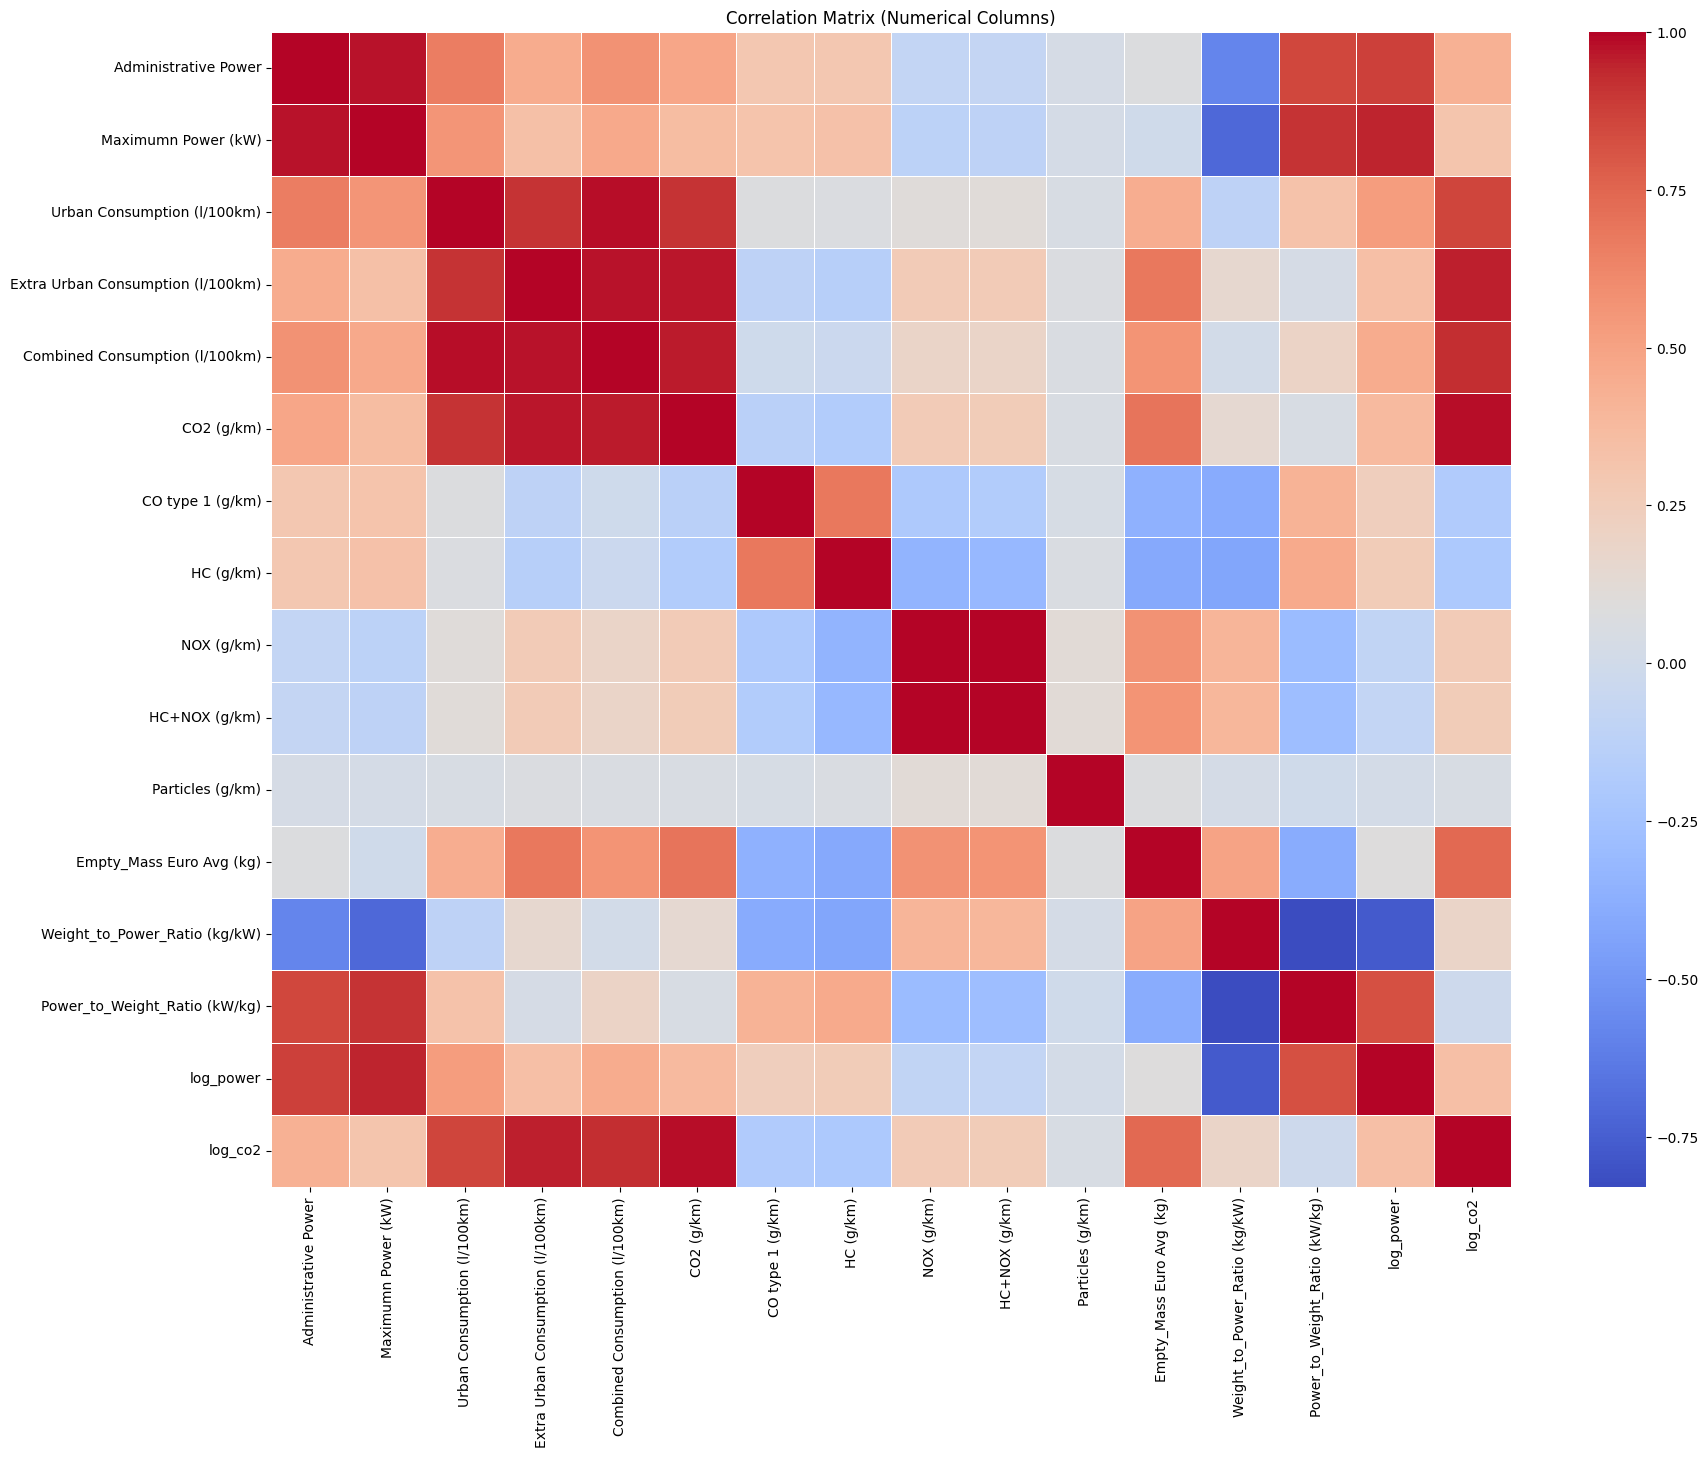

In [200]:
# Select numerical columns
numeric_data = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix for the numerical columns
numeric_correlation_matrix = numeric_data.corr()

# Display the heatmap of the correlation matrix for the numerical columns
plt.figure(figsize=(20, 15))
sns.heatmap(numeric_correlation_matrix, cmap='coolwarm', annot=False, linewidths=0.5)

plt.title('Correlation Matrix (Numerical Columns)')
plt.show()

## Weight-related analysis

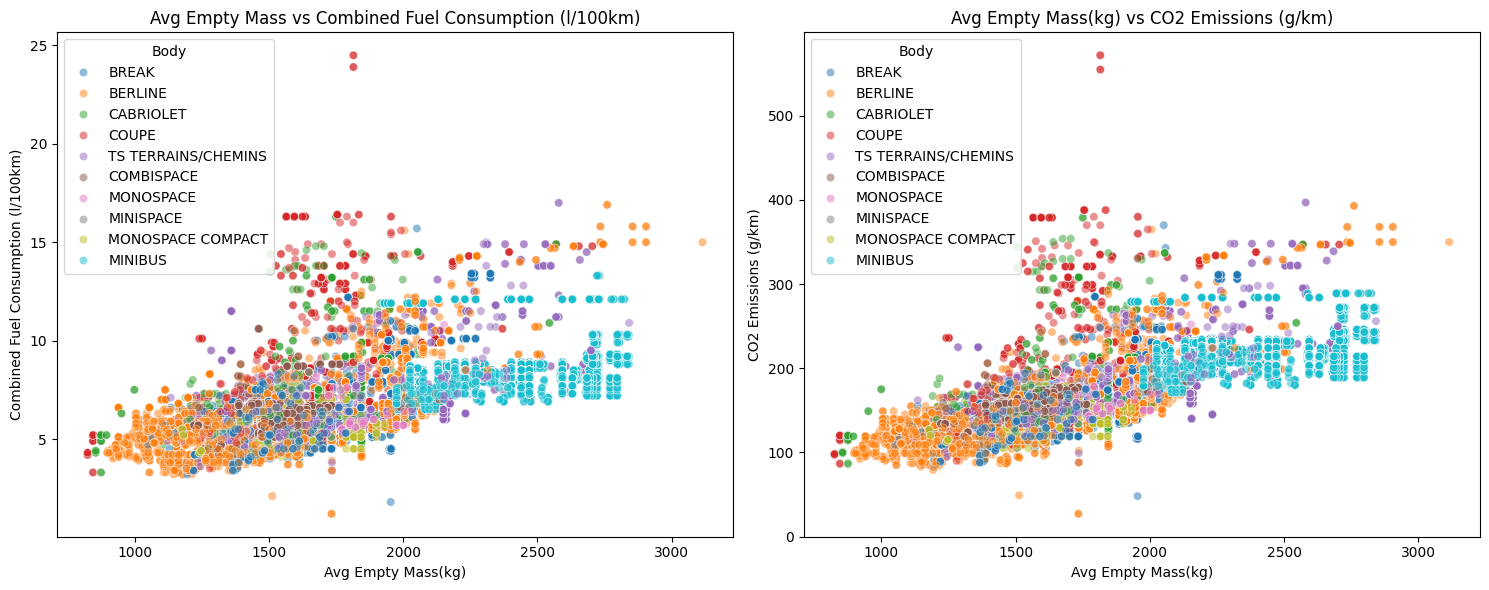

In [201]:
# Set the size of the plots
plt.figure(figsize=(15,6))

# Curb weight vs Combined fuel consumption
plt.subplot(1,2,1)
sns.scatterplot(
    x='Empty_Mass Euro Avg (kg)',
    y='Combined Consumption (l/100km)',
    data=df,
    color='royalblue',
    hue="Body",
    alpha=0.5
)

plt.title('Avg Empty Mass vs Combined Fuel Consumption (l/100km)')
plt.xlabel('Avg Empty Mass(kg)')
plt.ylabel('Combined Fuel Consumption (l/100km)')


# Curb weight vs CO2 emissions
plt.subplot(1,2,2)
sns.scatterplot(
    x='Empty_Mass Euro Avg (kg)',
    y='CO2 (g/km)',
    data=df,
    color='royalblue',
    hue="Body",
    alpha=0.5
)

plt.title('Avg Empty Mass(kg) vs CO2 Emissions (g/km)')
plt.xlabel('Avg Empty Mass(kg)')
plt.ylabel('CO2 Emissions (g/km)')


# Adjust spacing
plt.tight_layout()
plt.show()

### Clustering

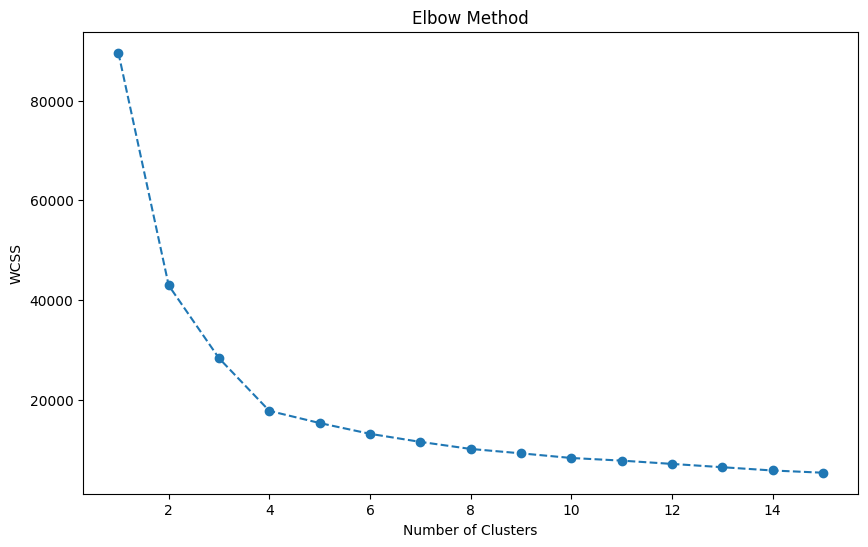

In [134]:
# Select variables for clustering
X = df[['Empty_Mass Euro Avg (kg)', 'Combined Consumption (l/100km)']]

# Drop rows with NaN values in the selected columns
X = X.dropna()

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Elbow method for clustering
wcss = []  # within-cluster sum of squares
max_clusters = 15

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the elbow method
plt.figure(figsize=(10,6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

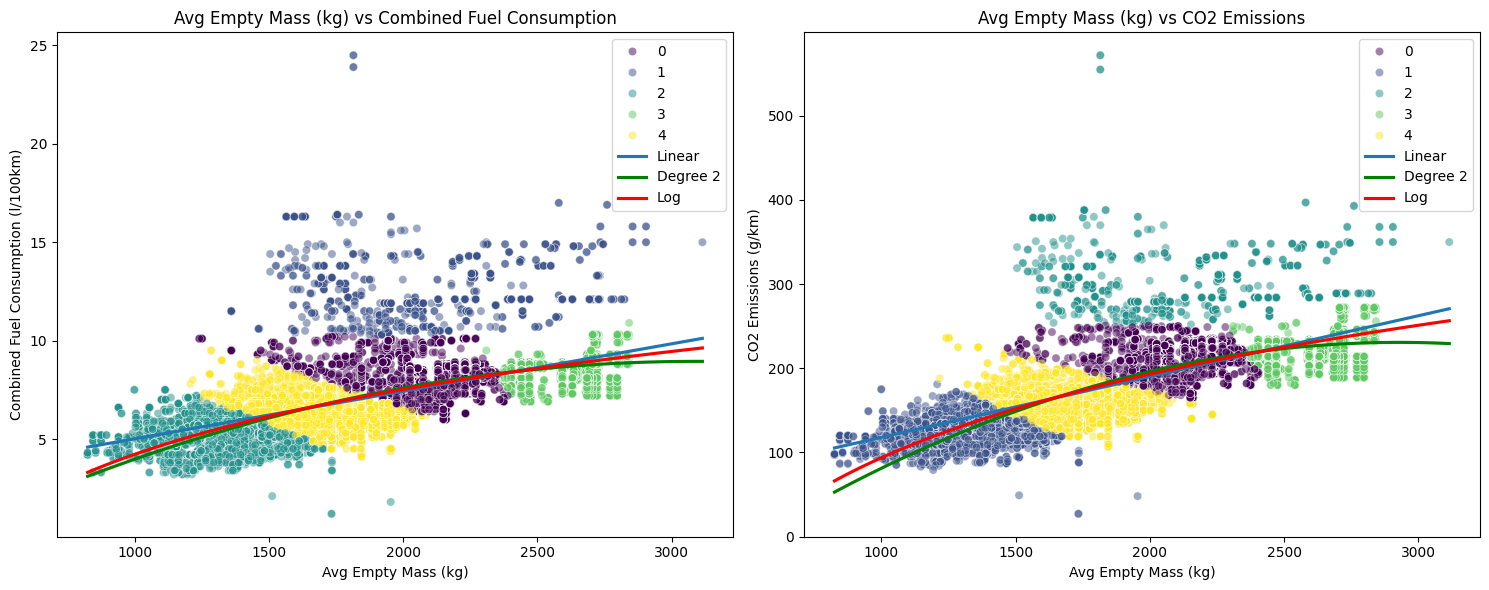

In [202]:
# Select data for clustering
cluster_data = df[['Empty_Mass Euro Avg (kg)', 'Combined Consumption (l/100km)']].dropna()

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_data['Cluster'] = kmeans.fit_predict(scaled_data)

# Set figure size
plt.figure(figsize=(15,6))

# Scatter plot for Weight vs Fuel Consumption
plt.subplot(1,2,1)
sns.scatterplot(
    x='Empty_Mass Euro Avg (kg)',
    y='Combined Consumption (l/100km)',
    hue='Cluster',
    data=cluster_data,
    palette='viridis',
    alpha=0.5
)

# Linear regression
sns.regplot(
    x='Empty_Mass Euro Avg (kg)',
    y='Combined Consumption (l/100km)',
    data=cluster_data,
    scatter=False,
    label='Linear'
)

# Polynomial regression
sns.regplot(
    x='Empty_Mass Euro Avg (kg)',
    y='Combined Consumption (l/100km)',
    data=cluster_data,
    scatter=False,
    order=2,
    color='green',
    label='Degree 2'
)

# Log regression
sns.regplot(
    x='Empty_Mass Euro Avg (kg)',
    y='Combined Consumption (l/100km)',
    data=cluster_data,
    scatter=False,
    logx=True,
    color='red',
    label='Log'
)

plt.title('Avg Empty Mass (kg) vs Combined Fuel Consumption')
plt.xlabel('Avg Empty Mass (kg)')
plt.ylabel('Combined Fuel Consumption (l/100km)')
plt.legend()


# Prepare data for second plot
cluster_data_2 = df[['Empty_Mass Euro Avg (kg)', 'CO2 (g/km)']].dropna()
scaled_data_2 = scaler.fit_transform(cluster_data_2)
cluster_data_2['Cluster'] = kmeans.fit_predict(scaled_data_2)

# Scatter plot for Weight vs CO2 emissions
plt.subplot(1,2,2)
sns.scatterplot(
    x='Empty_Mass Euro Avg (kg)',
    y='CO2 (g/km)',
    hue='Cluster',
    data=cluster_data_2,
    palette='viridis',
    alpha=0.5
)

# Linear regression
sns.regplot(
    x='Empty_Mass Euro Avg (kg)',
    y='CO2 (g/km)',
    data=cluster_data_2,
    scatter=False,
    label='Linear'
)

# Polynomial regression
sns.regplot(
    x='Empty_Mass Euro Avg (kg)',
    y='CO2 (g/km)',
    data=cluster_data_2,
    scatter=False,
    order=2,
    color='green',
    label='Degree 2'
)

# Log regression
sns.regplot(
    x='Empty_Mass Euro Avg (kg)',
    y='CO2 (g/km)',
    data=cluster_data_2,
    scatter=False,
    logx=True,
    color='red',
    label='Log'
)

plt.title('Avg Empty Mass (kg) vs CO2 Emissions')
plt.xlabel('Avg Empty Mass (kg)')
plt.ylabel('CO2 Emissions (g/km)')
plt.legend()

plt.tight_layout()
plt.show()

#

## Power related analysis

### Clustering

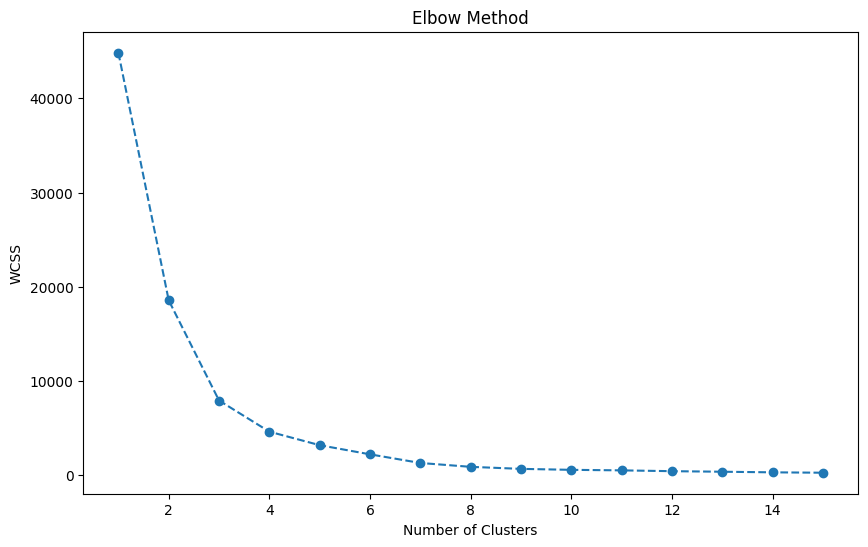

In [203]:
# Select data for clustering (Maximum Power)
cluster_data = df[['Maximumn Power (kW)']].dropna()

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Elbow method for clustering
wcss = []  # within-cluster sum of squares
max_clusters = 15

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the elbow method
plt.figure(figsize=(10,6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

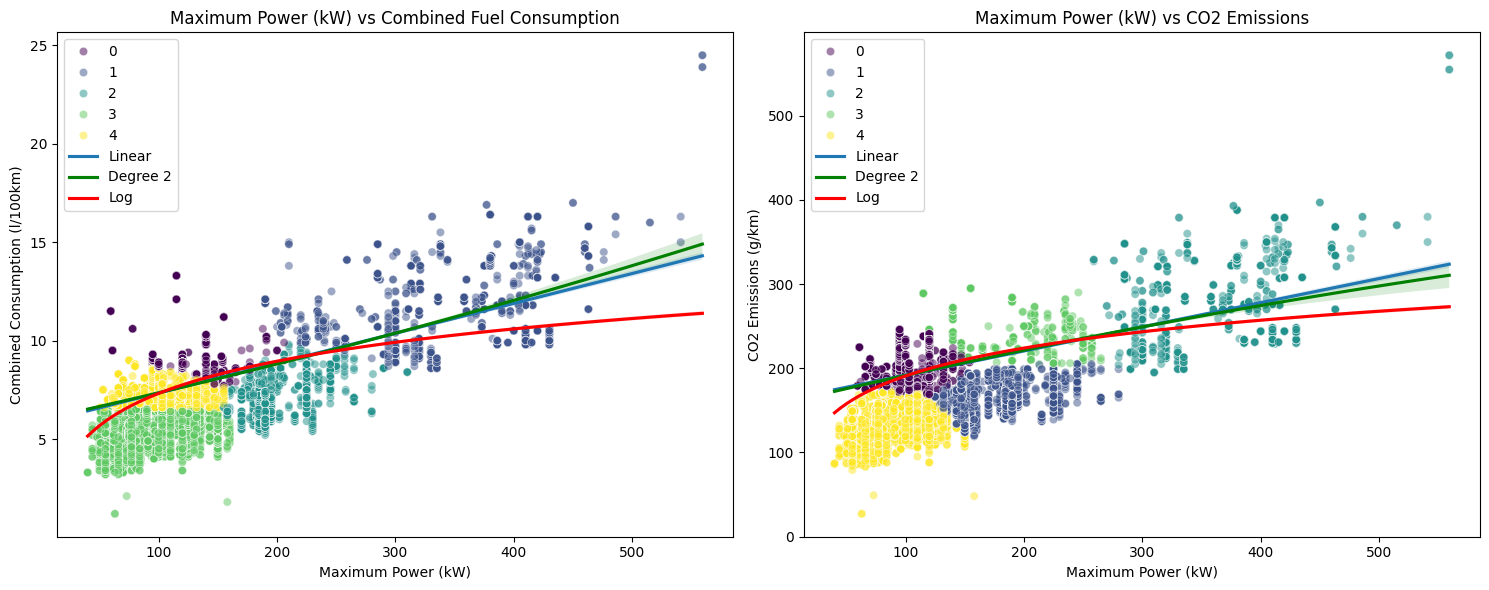

In [160]:
# Select data for clustering
cluster_data = df[['Maximumn Power (kW)', 'Combined Consumption (l/100km)']].dropna()

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_data['Cluster'] = kmeans.fit_predict(scaled_data)

# Set figure size
plt.figure(figsize=(15,6))

# Scatter plot for Maximum Power vs Fuel Consumption
plt.subplot(1,2,1)
sns.scatterplot(
    x='Maximumn Power (kW)',
    y='Combined Consumption (l/100km)',
    hue='Cluster',
    data=cluster_data,
    palette='viridis',
    alpha=0.5
)

# Linear regression
sns.regplot(
    x='Maximumn Power (kW)',
    y='Combined Consumption (l/100km)',
    data=cluster_data,
    scatter=False,
    label='Linear'
)

# Polynomial regression
sns.regplot(
    x='Maximumn Power (kW)',
    y='Combined Consumption (l/100km)',
    data=cluster_data,
    scatter=False,
    order=2,
    color='green',
    label='Degree 2'
)

# Log regression
sns.regplot(
    x='Maximumn Power (kW)',
    y='Combined Consumption (l/100km)',
    data=cluster_data,
    scatter=False,
    logx=True,
    color='red',
    label='Log'
)

plt.title('Maximum Power (kW) vs Combined Fuel Consumption')
plt.xlabel('Maximum Power (kW)')
plt.ylabel('Combined Consumption (l/100km)')
plt.legend()


# Prepare data for second plot
cluster_data_2 = df[['Maximumn Power (kW)', 'CO2 (g/km)']].dropna()
scaled_data_2 = scaler.fit_transform(cluster_data_2)
cluster_data_2['Cluster'] = kmeans.fit_predict(scaled_data_2)

# Scatter plot for Maximum Power vs CO2 emissions
plt.subplot(1,2,2)
sns.scatterplot(
    x='Maximumn Power (kW)',
    y='CO2 (g/km)',
    hue='Cluster',
    data=cluster_data_2,
    palette='viridis',
    alpha=0.5
)

# Linear regression
sns.regplot(
    x='Maximumn Power (kW)',
    y='CO2 (g/km)',
    data=cluster_data_2,
    scatter=False,
    label='Linear'
)

# Polynomial regression
sns.regplot(
    x='Maximumn Power (kW)',
    y='CO2 (g/km)',
    data=cluster_data_2,
    scatter=False,
    order=2,
    color='green',
    label='Degree 2'
)

# Log regression
sns.regplot(
    x='Maximumn Power (kW)',
    y='CO2 (g/km)',
    data=cluster_data_2,
    scatter=False,
    logx=True,
    color='red',
    label='Log'
)

plt.title('Maximum Power (kW) vs CO2 Emissions')
plt.xlabel('Maximum Power (kW)')
plt.ylabel('CO2 Emissions (g/km)')
plt.legend()

plt.tight_layout()
plt.show()

# Lowest and highest CO2 emitting vehicles

In [179]:
# Top 10 gasoline vehicles with the lowest CO2 emissions
top_10_essence = (
    df[df['Fuel'] == 'ES']
    .nsmallest(10, 'CO2 (g/km)')
)

# Top 10 diesel vehicles with the lowest CO2 emissions
top_10_diesel = (
    df[df['Fuel'] == 'GO']
    .nsmallest(10, 'CO2 (g/km)')
)

# Top 10 vehicles with the lowest CO2 emissions by vehicle segment (Gamme)
top_10_gamme = (
    df.groupby('Range', group_keys=False)
    .apply(lambda x: x.nsmallest(10, 'CO2 (g/km)'))
)

# Top 10 gasoline vehicles with the highest CO2 emissions
bottom_10_essence = (
    df[df['Fuel'] == 'ES']
    .nlargest(10, 'CO2 (g/km)')
)

# Display selected columns with fuel types indicated
print("Top 10 Gasoline Vehicles with Lowest CO2 Emissions:")
display(top_10_essence[['Brand', 'Folder Model', 'CO2 (g/km)']])

print("\nTop 10 Diesel Vehicles with Lowest CO2 Emissions:")
display(top_10_diesel[['Brand', 'Folder Model', 'CO2 (g/km)']])

print("\nTop 10 Vehicles with Lowest CO2 Emissions by Vehicle Segment (All Fuel Types):")
display(top_10_gamme[['Brand', 'Folder Model', 'Range', 'CO2 (g/km)']])

print("\nTop 10 Gasoline Vehicles with Highest CO2 Emissions:")
display(bottom_10_essence[['Brand', 'Folder Model', 'CO2 (g/km)']])

Top 10 Gasoline Vehicles with Lowest CO2 Emissions:


/tmp/ipykernel_255/2016880381.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nsmallest(10, 'CO2 (g/km)'))


,Brand,Folder Model,CO2 (g/km)
1442,FIAT,500,90.0
1476,FIAT,500C,90.0
1440,FIAT,500,92.0
1441,FIAT,500,92.0
1445,FIAT,500,92.0
1474,FIAT,500C,92.0
1475,FIAT,500C,92.0
1479,FIAT,500C,92.0
41942,MITSUBISHI,SPACE STAR,92.0
1443,FIAT,500,95.0



Top 10 Diesel Vehicles with Lowest CO2 Emissions:


,Brand,Folder Model,CO2 (g/km)
42961,RENAULT,CLIO,83.0
42968,RENAULT,CLIO,83.0
2347,HYUNDAI,I 20,84.0
2634,KIA,RIO,85.0
2635,KIA,RIO,85.0
43103,RENAULT,TWINGO,85.0
43104,RENAULT,TWINGO,85.0
43612,SMART,FORTWO,86.0
43636,SMART,FORTWO,86.0
1101,CITROEN,C3,87.0



Top 10 Vehicles with Lowest CO2 Emissions by Vehicle Segment (All Fuel Types):


,Brand,Folder Model,Range,CO2 (g/km)
43103,RENAULT,TWINGO,ECONOMIQUE,85.0
43104,RENAULT,TWINGO,ECONOMIQUE,85.0
43612,SMART,FORTWO,ECONOMIQUE,86.0
43636,SMART,FORTWO,ECONOMIQUE,86.0
43613,SMART,FORTWO,ECONOMIQUE,87.0
...,...,...,...,...
4597,MERCEDES-BENZ,CLASSE C,SUPERIEURE,109.0
4598,MERCEDES-BENZ,CLASSE C,SUPERIEURE,109.0
43028,RENAULT,MEGANE,SUPERIEURE,110.0
580,BMW,SERIE 3,SUPERIEURE,112.0



Top 10 Gasoline Vehicles with Highest CO2 Emissions:


,Brand,Folder Model,CO2 (g/km)
116,ASTON MARTIN,ONE-77,572.0
118,ASTON MARTIN,ONE-77,572.0
115,ASTON MARTIN,ONE-77,555.0
117,ASTON MARTIN,ONE-77,555.0
8457,MERCEDES-BENZ,CLASSE G,397.0
8458,MERCEDES-BENZ,CLASSE G,397.0
443,BENTLEY,MULSANNE,393.0
444,BENTLEY,MULSANNE,393.0
141,ASTON MARTIN,V12 VANTAGE,388.0
142,ASTON MARTIN,V12 VANTAGE,388.0


# Predictive Modeling

In [195]:
# Define all relevant columns for the model and create a temporary DataFrame to handle NaNs
all_model_cols = ['Body','Fuel','Maximumn Power (kW)','Empty_Mass Euro Avg (kg)','Gearbox', 'CO2 (g/km)']
model_data = df[all_model_cols].dropna()

# Features and target
X = model_data[['Body','Fuel','Maximumn Power (kW)','Empty_Mass Euro Avg (kg)','Gearbox']]
y = model_data['CO2 (g/km)']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_features = ['Body', 'Fuel', 'Gearbox']
numeric_features = ['Maximumn Power (kW)', 'Empty_Mass Euro Avg (kg)']

# Preprocessing for linear models
preprocessing_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

# Preprocessing for tree models
preprocessing_tree = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Models
models = {
    "Linear Regression": Pipeline([
        ('preprocessing', preprocessing_scaled),
        ('model', LinearRegression())
    ]),

    "Ridge": Pipeline([
        ('preprocessing', preprocessing_scaled),
        ('model', Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ('preprocessing', preprocessing_scaled),
        ('model', Lasso(alpha=0.1))
    ]),

    "Random Forest": Pipeline([
        ('preprocessing', preprocessing_tree),
        ('model', RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ('preprocessing', preprocessing_tree),
        ('model', GradientBoostingRegressor(random_state=42))
    ])
}

# Compare overfitting
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "R2_Gap": train_r2 - test_r2,
        "Train_MAE": train_mae,
        "Test_MAE": test_mae,
        "MAE_Gap": test_mae - train_mae
    })

results_df = pd.DataFrame(results).sort_values(by="Test_R2", ascending=False)
display(results_df)

,Model,Train_R2,Test_R2,R2_Gap,Train_MAE,Test_MAE,MAE_Gap
3,Random Forest,0.968224,0.963026,0.005198,5.264746,5.565201,0.300455
4,Gradient Boosting,0.936864,0.934980,0.001884,7.276422,7.348821,0.072400
0,Linear Regression,0.859037,0.854502,0.004534,10.799337,10.882887,0.083550
1,Ridge,0.859007,0.854466,0.004541,10.800228,10.883413,0.083185
2,Lasso,0.848219,0.846095,0.002124,11.147018,11.176332,0.029314
